# 📘 Pre-Workshop Notebook 1: Foundations of Brain and Behavioral Research Workflows
## Scientific Workflows for Brain and Behavioral Research
### National Science Foundation Supported Learning Initiative (Award No. OAC-2417875)

---

## 📋 Set Up Your Profile
*Run the cell below to record your name and institution in this notebook.*

In [ ]:
# PROFILE SETUP
student_name = "Uzair Ahmad"
institution = "National Univeristy of Computer and Emerging Sciences, Pakistani"
research_area = "Computer Vision, Machine Learning"

print(f"✅ Notebook initialized for {student_name} ({institution})")
print(f"Research area: {research_area}")

---

## 🤖 Using AI Tools to Build Your Workflow ("Ask → Build → Document")

Welcome to a different way of learning to work with data! In this notebook, you will not be memorizing programming syntax. Instead, you will act as a **Workflow Designer** — someone who decides *what* a workflow should do and then uses AI tools (such as Claude, ChatGPT, or GitHub Copilot) to help generate the code.

To get the most out of each activity, follow this three-step cycle:
1. **Ask:** Copy the suggested prompt below into your preferred AI tool. Adjust it to fit your research area if you like.
2. **Build:** Paste the AI-generated code into the empty code cell below the prompt, then run it and look at what it produces.
3. **Document:** In the reflection box that follows, write in plain language what the code did and what it taught you about the concept.

---
## 🧠 Part A: How Brain Data Is Captured and Used
### Topic: Brain-Machine Interfaces (BMIs), Brain Imaging (fMRI), and Real-Time Systems

This section introduces two of the most important types of brain and behavioral data used in modern neuroscience research, and how analysis workflows process them.

### 🧭 Activity A.1 — Simulating a Brain-Machine Interface Decoder

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a neuroscience research assistant helping a biology student understand brain-machine interfaces. Write a Python script using NumPy and Matplotlib that simulates how brain signals from the motor cortex can be used to control a robotic limb. The script should:
> 1. Generate 2 seconds of synthetic data representing voltage recordings from 64 brain electrodes, sampled 1000 times per second, including realistic background noise and a few sudden signal spikes representing muscle movements.
> 2. Write a simple decoding function that converts these raw voltage patterns into X and Y position coordinates representing the intended movement of a robotic limb.
> 3. Plot the raw electrode signals and the resulting decoded movement path side-by-side.
> Add plain-language comments throughout explaining what each step does and what the numbers represent."

Saved figure to bmi_simulation.png

Decoder accuracy check
----------------------------------------------
  intended   30.0°  ->  decoded   28.0°   (off by 2.0°)
  intended  150.0°  ->  decoded  149.9°   (off by 0.1°)
  intended  280.0°  ->  decoded  278.4°   (off by 1.6°)
----------------------------------------------
Errors of a few degrees are expected: the spikes are random, so
each electrode's vote is noisy. More electrodes = smaller error.


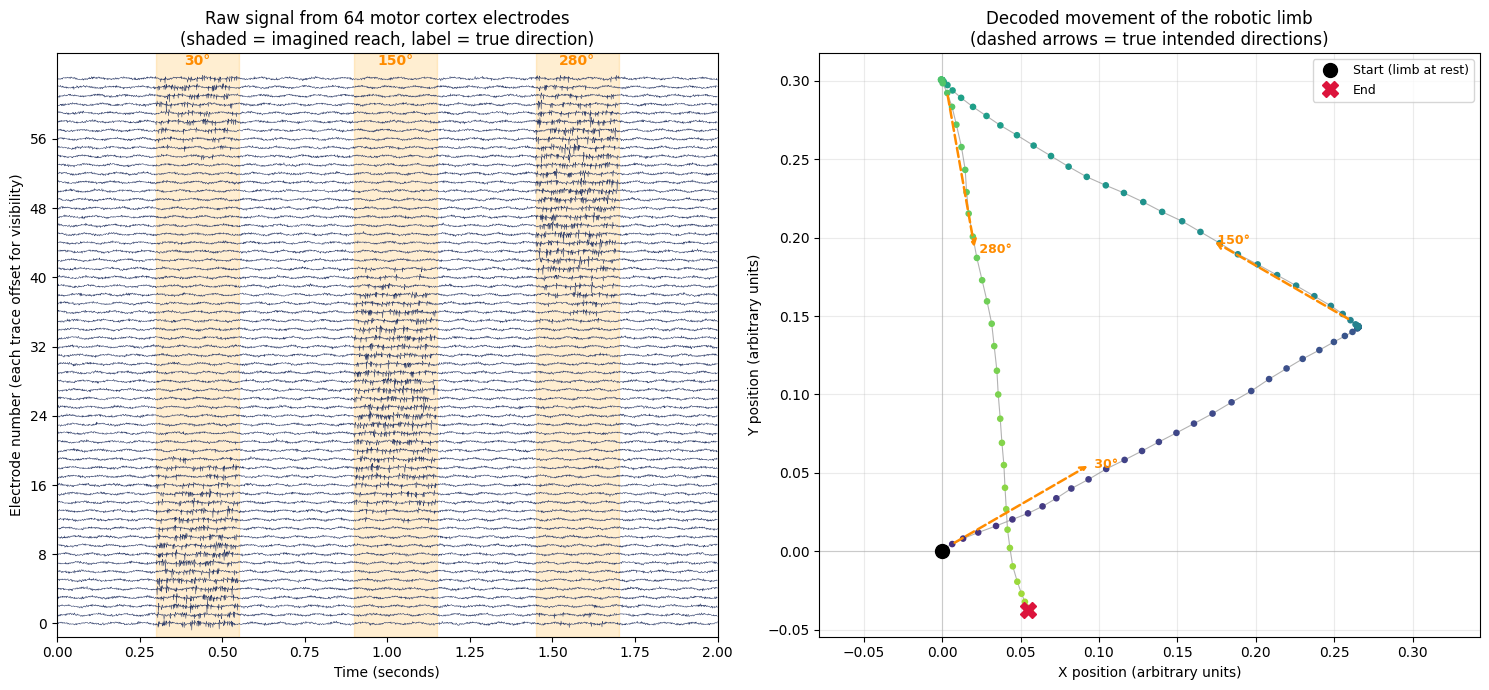

In [1]:
"""
====================================================================
 BRAIN-MACHINE INTERFACE (BMI) SIMULATION
 A toy model of how motor cortex activity is turned into robot motion
====================================================================

THE BIG PICTURE
---------------
When you decide to reach for a coffee cup, neurons in your motor cortex
fire. Individual neurons don't each encode "cup" -- instead each neuron
has a PREFERRED DIRECTION. It fires hardest when your arm moves one
particular way, less when the movement is off-angle, and barely at all
for the opposite direction. This is called COSINE TUNING
(Georgopoulos et al., 1982).

No single neuron knows where the arm is going. But if you record from
many neurons at once and let each one "vote" for its preferred direction
(weighted by how hard it is firing), the votes add up to the true
movement direction. That sum is called the POPULATION VECTOR, and it is
the core idea behind real implanted BMIs like BrainGate.

This script does three things:
  PART 1 -- fake 64-electrode recording with noise + movement bursts
  PART 2 -- a decoder that turns voltages into (X, Y) robot coordinates
  PART 3 -- side-by-side plots of the raw brain data and the robot path

Everything here is SYNTHETIC. We invent the brain data ourselves, which
means we know the right answer and can check whether the decoder finds it.
"""

import numpy as np
import matplotlib.pyplot as plt

# A fixed random seed means the "random" noise is the same every run.
# Handy for teaching: your plot will look like everyone else's.
rng = np.random.default_rng(42)


# ====================================================================
# PART 1: GENERATE SYNTHETIC ELECTRODE DATA
# ====================================================================

# ---- Recording settings -------------------------------------------
FS = 1000            # sampling rate in Hz: we measure voltage 1000x/second
DURATION = 2.0       # seconds of recording
N_CHANNELS = 64      # 64 electrodes, like a real Utah array implant
N_SAMPLES = int(FS * DURATION)   # 1000 * 2 = 2000 voltage readings/channel

# Time axis: 2000 evenly spaced values from 0 to 2 seconds.
# time[0] = 0.000 s, time[1] = 0.001 s, ... time[1999] = 1.999 s
time = np.arange(N_SAMPLES) / FS

# ---- Give every electrode a preferred direction --------------------
# We spread 64 electrodes evenly around a circle (0 to 360 degrees).
# Electrode 0 "likes" rightward movement, electrode 16 likes up, etc.
# In a real implant you don't know these angles in advance -- you learn
# them by asking the patient to imagine moving in known directions.
preferred_directions = np.linspace(0, 2 * np.pi, N_CHANNELS, endpoint=False)

# ---- Background noise ----------------------------------------------
# Real neural recordings are never silent. Two things are always there:

# (a) Thermal/electronic noise: random jitter, different on each electrode.
#     std=15 means typical wobble is about +/- 15 microvolts (uV).
noise = rng.normal(loc=0.0, scale=15.0, size=(N_CHANNELS, N_SAMPLES))

# (b) Local field potential (LFP): a slow ~12 Hz brain rhythm that whole
#     patches of cortex share. Amplitude ~25 uV. Each electrode sees it
#     at a slightly different phase because it sits somewhere different.
lfp_phase = rng.uniform(0, 2 * np.pi, size=(N_CHANNELS, 1))
lfp = 25.0 * np.sin(2 * np.pi * 12.0 * time[None, :] + lfp_phase)

# Start the recording as noise + slow rhythm. Shape is (64, 2000):
# 64 rows (one per electrode), 2000 columns (one per millisecond).
signals = noise + lfp

# ---- Movement events -----------------------------------------------
# Now we add the interesting part: three imagined reaches. Each one is a
# burst of spiking activity lasting 250 ms, aimed in a known direction.
#   onset  = when the reach starts (seconds)
#   angle  = true intended direction in radians (0 = right, pi/2 = up)
movements = [
    {"onset": 0.30, "angle": np.deg2rad(30)},    # up and to the right
    {"onset": 0.90, "angle": np.deg2rad(150)},   # up and to the left
    {"onset": 1.45, "angle": np.deg2rad(280)},   # down and slightly right
]
BURST_DURATION = 0.25        # each reach lasts 250 milliseconds
SPIKE_AMPLITUDE = 90.0       # a neural spike is ~90 uV: 6x taller than noise
PEAK_SPIKE_RATE = 120.0      # a well-tuned electrode fires ~120 spikes/second

for mv in movements:
    # Convert times to sample indices (0.30 s * 1000 Hz = sample 300)
    start = int(mv["onset"] * FS)
    stop = start + int(BURST_DURATION * FS)

    # COSINE TUNING, the key line of the whole simulation.
    # For each electrode, compare its preferred direction to the movement
    # direction. cos() gives 1.0 for a perfect match, 0 at 90 degrees off,
    # negative for the opposite direction. We clip negatives to zero
    # because a neuron can't fire fewer than zero spikes.
    tuning = np.clip(np.cos(preferred_directions - mv["angle"]), 0, None)

    for ch in range(N_CHANNELS):
        # Electrodes pointing the right way fire a lot; others barely fire.
        rate = PEAK_SPIKE_RATE * tuning[ch]
        n_spikes = rng.poisson(rate * BURST_DURATION)   # Poisson = random timing
        if n_spikes == 0:
            continue

        # Scatter those spikes randomly through the burst window and add a
        # sharp voltage deflection at each one. Real spikes are biphasic
        # (a fast dip then a rebound), so we use a 3-sample shape.
        spike_times = rng.integers(start, stop - 3, size=n_spikes)
        for t in spike_times:
            signals[ch, t]     -= SPIKE_AMPLITUDE          # sharp negative dip
            signals[ch, t + 1] += SPIKE_AMPLITUDE * 0.55   # rebound upward
            signals[ch, t + 2] += SPIKE_AMPLITUDE * 0.15   # small tail


# ====================================================================
# PART 2: THE DECODER -- voltages in, robot arm coordinates out
# ====================================================================

def decode_movement(signals, preferred_directions, fs=1000,
                    window_ms=50, step_ms=10, gain=0.9):
    """
    Turn raw electrode voltages into an (X, Y) path for a robotic limb.

    Four stages, same as a real BMI decoder:
      1. Filter out the slow LFP rhythm, keeping only fast spikes.
      2. Measure how much spiking each electrode did, in short time bins.
      3. Let each electrode vote for its preferred direction -> velocity.
      4. Add up velocity over time -> position.

    Returns
    -------
    bin_times : when each decoded sample happened (seconds)
    x, y      : robot limb coordinates at each of those times
    speed     : how fast the limb was moving, useful for the plot colors
    """

    # ---- STAGE 1: high-pass filter ---------------------------------
    # The 12 Hz LFP wave is slow and large; spikes are fast and brief.
    # We compute a 21 ms running average (which captures the slow wave)
    # and subtract it. What's left is the fast spiking activity.
    kernel = np.ones(21) / 21
    smooth = np.apply_along_axis(
        lambda row: np.convolve(row, kernel, mode="same"), axis=1, arr=signals
    )
    highpass = signals - smooth

    # ---- STAGE 2: measure activity in sliding windows ---------------
    # We can't decode from single milliseconds -- too noisy. Instead we
    # look at 50 ms chunks and ask "how much spiking happened here?"
    # We slide the window forward 10 ms at a time, so windows overlap
    # and the output path comes out smooth (100 updates per second).
    win = int(window_ms * fs / 1000)     # 50 samples per window
    step = int(step_ms * fs / 1000)      # slide by 10 samples
    starts = np.arange(0, signals.shape[1] - win, step)

    # "Power" = mean squared voltage. Squaring makes negative dips count
    # as much as positive peaks, so both halves of a spike contribute.
    power = np.array([
        np.mean(highpass[:, s:s + win] ** 2, axis=1) for s in starts
    ])                                    # shape: (n_windows, 64 electrodes)

    # ---- STAGE 3: population vector ---------------------------------
    # Each electrode has its own baseline noise level, and some electrodes
    # are noisier than others. The median power over the whole recording
    # is a good estimate of "this electrode at rest" -- movements are brief,
    # so most windows are resting windows and the median ignores the bursts.
    baseline = np.median(power, axis=0)

    # How far above its own resting level is each electrode right now?
    # Dividing by baseline puts every electrode on the same scale, so a
    # noisy electrode doesn't outshout a quiet one. Negatives -> 0.
    modulation = np.clip((power - baseline) / baseline, 0, None)

    # Each electrode's vote is a unit arrow pointing its preferred way.
    vote_x = np.cos(preferred_directions)
    vote_y = np.sin(preferred_directions)

    # Weighted sum of all 64 votes = the population vector = velocity.
    # Electrodes firing hard pull the arrow toward their direction;
    # silent electrodes contribute nothing.
    vx = gain * (modulation @ vote_x) / len(preferred_directions)
    vy = gain * (modulation @ vote_y) / len(preferred_directions)

    # ---- STAGE 4: velocity -> position ------------------------------
    # The population vector says which way and how fast to move, not where
    # to be. Position is the running total of velocity (integration).
    # Multiply by the time between updates (0.01 s) to get distance.
    dt = step / fs
    x = np.cumsum(vx) * dt
    y = np.cumsum(vy) * dt

    bin_times = (starts + win / 2) / fs   # label each window by its center
    speed = np.sqrt(vx ** 2 + vy ** 2)
    return bin_times, x, y, speed


bin_times, x_path, y_path, speed = decode_movement(signals, preferred_directions)


# ====================================================================
# PART 3: VISUALIZE
# ====================================================================

fig, (ax_raw, ax_path) = plt.subplots(1, 2, figsize=(15, 7))

# ---- LEFT PANEL: the raw brain recording ---------------------------
# All 64 channels on one axis would overlap into mush, so we stack them:
# channel 0 at the bottom, channel 63 at the top, each shifted up by a
# fixed offset. This is exactly how neuroscientists view real array data.
OFFSET = 260   # vertical gap between channels, in microvolts
for ch in range(N_CHANNELS):
    ax_raw.plot(time, signals[ch] + ch * OFFSET, linewidth=0.35, color="#2b3a67")

# Mark when each imagined reach happened. You should be able to SEE the
# bursts here as dark vertical thickening -- and notice that different
# bands of channels light up for different movement directions.
for mv in movements:
    ax_raw.axvspan(mv["onset"], mv["onset"] + BURST_DURATION,
                   color="orange", alpha=0.18, zorder=0)
    ax_raw.text(mv["onset"] + BURST_DURATION / 2, N_CHANNELS * OFFSET + 150,
                f"{round(np.rad2deg(mv['angle']))}°",
                ha="center", fontsize=10, color="darkorange", weight="bold")

ax_raw.set_title("Raw signal from 64 motor cortex electrodes\n"
                 "(shaded = imagined reach, label = true direction)", fontsize=12)
ax_raw.set_xlabel("Time (seconds)")
ax_raw.set_ylabel("Electrode number (each trace offset for visibility)")
ax_raw.set_yticks(np.arange(0, N_CHANNELS, 8) * OFFSET)
ax_raw.set_yticklabels(np.arange(0, N_CHANNELS, 8))
ax_raw.set_xlim(0, DURATION)
ax_raw.set_ylim(-400, N_CHANNELS * OFFSET + 500)   # headroom for the angle labels

# ---- RIGHT PANEL: the decoded robot limb path ----------------------
# Color the path by time so you can follow the order of the movements:
# dark purple at t=0, bright yellow at t=2 s.
ax_path.scatter(x_path, y_path, c=bin_times, cmap="viridis", s=14, zorder=3)
ax_path.plot(x_path, y_path, color="grey", linewidth=0.8, alpha=0.6, zorder=2)
ax_path.plot(x_path[0], y_path[0], "o", color="black", markersize=10,
             label="Start (limb at rest)", zorder=4)
ax_path.plot(x_path[-1], y_path[-1], "X", color="crimson", markersize=12,
             label="End", zorder=4)

# Overlay the TRUE direction of each reach as a dashed orange arrow, drawn
# from the point where the limb was when that reach began. If the decoder
# works, each leg of the path should run parallel to its arrow.
arrow_len = 0.30 * max(np.ptp(x_path), np.ptp(y_path))
tips = []
for mv in movements:
    # Which decoded sample is closest to the moment this reach started?
    i0 = np.argmin(np.abs(bin_times - mv["onset"]))
    x0, y0 = x_path[i0], y_path[i0]
    x1 = x0 + arrow_len * np.cos(mv["angle"])
    y1 = y0 + arrow_len * np.sin(mv["angle"])
    tips.append((x1, y1))
    ax_path.annotate("", xy=(x1, y1), xytext=(x0, y0),
                     arrowprops=dict(arrowstyle="->", linestyle="--",
                                     color="darkorange", linewidth=1.8))
    ax_path.text(x1, y1, f" {round(np.rad2deg(mv['angle']))}°", fontsize=9,
                 color="darkorange", weight="bold", va="center")

# annotate() arrows don't count toward the automatic axis limits, so we plot
# the arrow tips invisibly to make sure none of them get cropped off.
tips = np.array(tips)
ax_path.scatter(tips[:, 0], tips[:, 1], alpha=0, s=1)

ax_path.set_title("Decoded movement of the robotic limb\n"
                  "(dashed arrows = true intended directions)", fontsize=12)
ax_path.set_xlabel("X position (arbitrary units)")
ax_path.set_ylabel("Y position (arbitrary units)")
ax_path.axhline(0, color="lightgrey", linewidth=0.8, zorder=1)
ax_path.axvline(0, color="lightgrey", linewidth=0.8, zorder=1)
ax_path.set_aspect("equal", adjustable="datalim")
ax_path.legend(loc="best", fontsize=9)
ax_path.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("bmi_simulation.png", dpi=150)
print("Saved figure to bmi_simulation.png")


# ====================================================================
# HOW WELL DID THE DECODER DO? (printed to the terminal)
# ====================================================================
# For each movement we compare the direction the limb actually travelled
# during that burst against the direction we told it to travel.
print("\nDecoder accuracy check")
print("-" * 46)
for mv in movements:
    # Find the decoded samples that fall inside this movement window
    inside = (bin_times >= mv["onset"]) & (bin_times <= mv["onset"] + BURST_DURATION)
    # Net displacement = where the limb ended up minus where it started
    dx = x_path[inside][-1] - x_path[inside][0]
    dy = y_path[inside][-1] - y_path[inside][0]
    decoded_angle = np.rad2deg(np.arctan2(dy, dx)) % 360
    true_angle = np.rad2deg(mv["angle"]) % 360
    # Wrap the error into the range -180..180 so 359 vs 1 counts as 2, not 358
    error = (decoded_angle - true_angle + 180) % 360 - 180
    print(f"  intended {true_angle:6.1f}°  ->  decoded {decoded_angle:6.1f}°"
          f"   (off by {abs(error):.1f}°)")
print("-" * 46)
print("Errors of a few degrees are expected: the spikes are random, so\n"
      "each electrode's vote is noisy. More electrodes = smaller error.")

### 🧭 Activity A.2 — Simulating Brain Imaging (fMRI) Data

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a neuroscience instructor explaining fMRI to a biology student. Write a Python script that builds a simplified simulation of a functional brain imaging dataset. The script should:
> 1. Create a small 3D grid of brain regions (10 x 10 x 10 grid points), each observed across 15 time points — representing a short fMRI recording session.
> 2. Simulate a realistic brain activity pattern where a specific region becomes active (increases its signal) and then returns to baseline, mimicking what happens when a participant performs a task.
> 3. Add a simple head movement correction step: introduce a small artificial shift in the data across time points, then show how a correction routine detects and compensates for this.
> 4. Display a plot showing how the signal changes over time in an active brain region compared to an inactive one.
> Use plain-language comments to explain what each step represents biologically."

Motion correction results
----------------------------------------------------
 time   true shift    estimated shift    match?
   0    ( 0, 0)         ( 0, 0)           yes
   1    ( 0, 0)         ( 0, 0)           yes
   2    ( 1, 0)         ( 1, 0)           yes
   3    ( 1, 0)         ( 1, 0)           yes
   4    ( 1, 0)         ( 1, 0)           yes
   5    ( 2, 0)         ( 2, 0)           yes
   6    ( 2, 0)         ( 2, 0)           yes
   7    ( 2, 2)         ( 2, 2)           yes
   8    ( 1, 2)         ( 1, 2)           yes
   9    ( 1, 0)         ( 1, 0)           yes
  10    ( 0, 0)         ( 0, 0)           yes
  11    ( 0, 0)         ( 0, 0)           yes
  12    ( 0, 0)         ( 0, 0)           yes
  13    ( 0, 0)         ( 0, 0)           yes
  14    ( 0, 0)         ( 0, 0)           yes
----------------------------------------------------

Active voxel error vs ground truth:
  before correction: 24.31 percentage points
  after correction:  0.65 percentage points
  mo

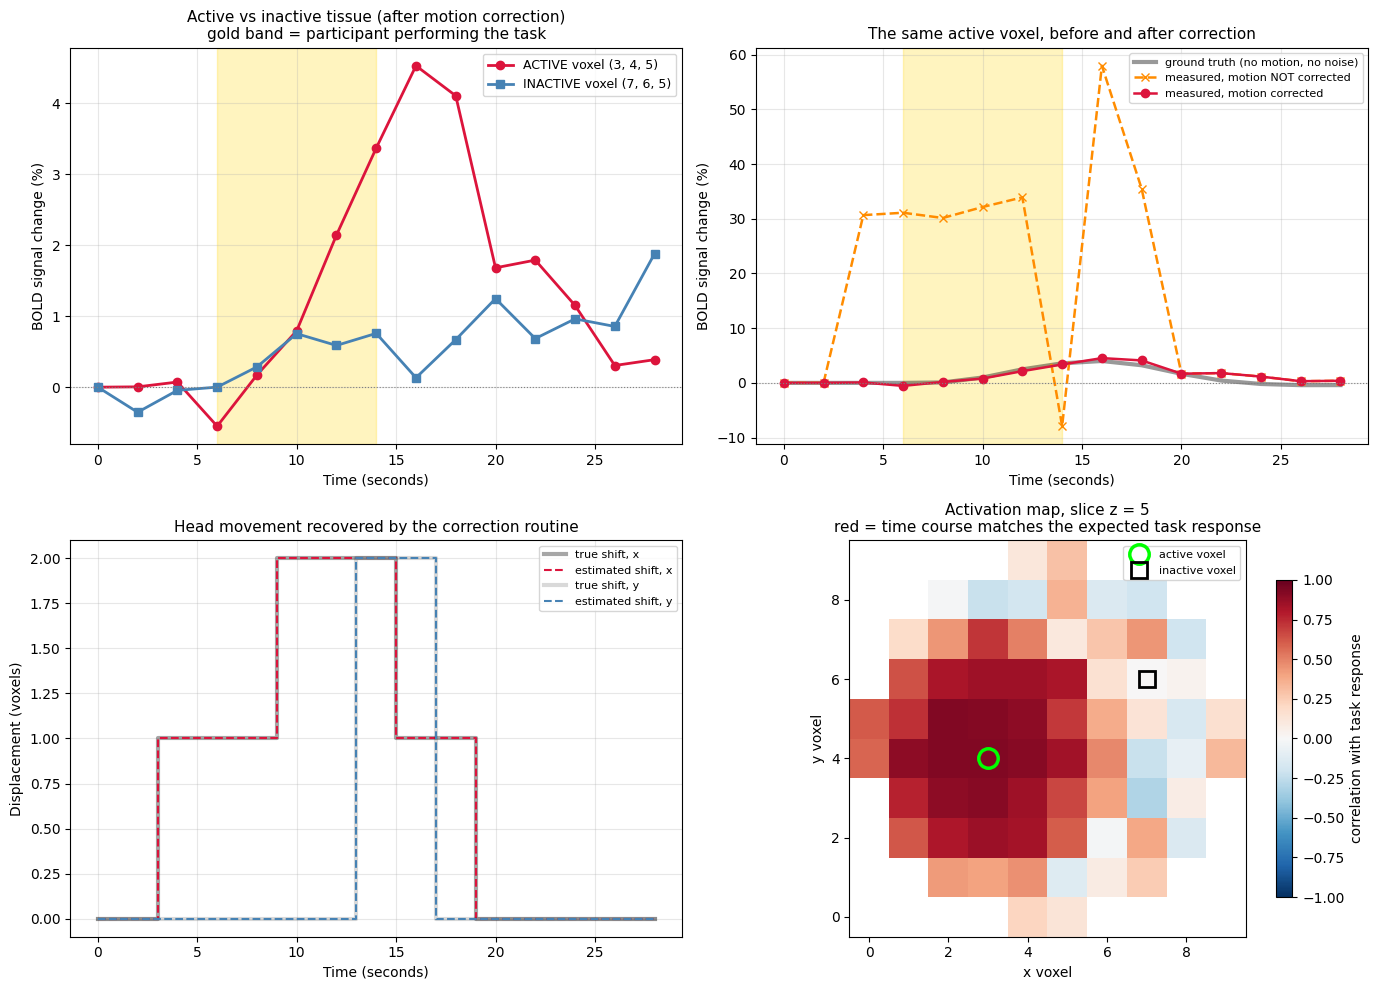

In [2]:
"""
====================================================================
 A SIMPLIFIED fMRI SIMULATION
 What a functional brain scan actually measures, and why we have to
 correct for the fact that the participant's head keeps moving
====================================================================

WHAT fMRI ACTUALLY MEASURES
---------------------------
An MRI scanner does NOT measure neurons firing. It measures blood.

When a patch of cortex gets busy, it needs more oxygen, so the brain
over-delivers fresh oxygenated blood to that patch. Oxygenated and
deoxygenated haemoglobin have different magnetic properties, so the
local MRI signal changes. This is the BOLD signal -- Blood Oxygen
Level Dependent.

Two consequences shape everything below:

  1. BOLD is SLOW. Neurons respond in milliseconds, but blood flow
     takes ~6 seconds to peak and ~20 seconds to settle, often
     dipping below baseline first. The shape of that lag is called
     the HAEMODYNAMIC RESPONSE FUNCTION (HRF).

  2. BOLD is SMALL. A strong activation changes the signal by 1-5%.
     The head only has to move a millimetre or two for the resulting
     artefact to be LARGER than the effect we are hunting for. That
     is why motion correction is not optional.

THE DATA STRUCTURE
------------------
An fMRI dataset is a 4D array: three space dimensions plus time.
Here we use a 10 x 10 x 10 grid of VOXELS ("volume pixels", 3D cubes
of tissue) measured at 15 TIME POINTS. Each time point is one whole
brain volume. The gap between volumes is the TR (repetition time),
2 seconds here, so this is a 30-second session.

The script runs in four parts:
  PART 1 -- build the brain and the true task-driven activation
  PART 2 -- add realistic nuisance: drift, noise, and head motion
  PART 3 -- detect the motion and undo it
  PART 4 -- plot active vs inactive tissue, before and after correction
"""

import math

import numpy as np
import matplotlib.pyplot as plt

# Fixed seed so the "random" noise is identical every run.
rng = np.random.default_rng(7)


# ====================================================================
# PART 1: BUILD THE BRAIN AND THE TASK RESPONSE
# ====================================================================

# ---- Scan parameters -----------------------------------------------
GRID = 10            # 10 x 10 x 10 voxels
N_TIME = 15          # 15 brain volumes collected
TR = 2.0             # seconds between volumes
scan_times = np.arange(N_TIME) * TR      # 0, 2, 4, ... 28 seconds

# ---- Anatomy --------------------------------------------------------
# Real brains are not uniform grey blocks: grey matter, white matter and
# ventricles all give different baseline intensities. We need that
# structure for a biological reason AND a practical one. Biologically it
# is what a real image looks like; practically, the motion-correction
# step in Part 3 works by matching image features between time points.
# A featureless block would slide around without anything to lock onto.

coords = np.indices((GRID, GRID, GRID))          # x, y, z index of every voxel
centre = (GRID - 1) / 2
dist = np.sqrt(sum((c - centre) ** 2 for c in coords))   # distance from centre

# A soft sphere = "head". Voxels near the centre are inside the brain,
# voxels at the corners are outside it (air, essentially no signal).
brain_mask = 1 / (1 + np.exp((dist - 4.0) * 2.0))        # smooth 0-to-1 edge

# Baseline intensity in arbitrary scanner units. Tissue nearer the centre
# is a bit brighter, plus a gentle texture so no two regions look alike.
anatomy = 1000 * brain_mask * (1 + 0.25 * np.cos(coords[0] * 0.9)
                                 + 0.20 * np.sin(coords[1] * 1.1)
                                 + 0.15 * np.cos(coords[2] * 0.7))

# ---- The task -------------------------------------------------------
# The participant does something (say, tapping their fingers) from
# 6 seconds to 14 seconds into the scan. Before and after, they rest.
TASK_ON, TASK_OFF = 6.0, 14.0

# ---- The haemodynamic response function -----------------------------
def hrf(t):
    """
    The canonical HRF: how the BOLD signal answers one instant of
    neural firing. Built from two gamma functions -- a big positive
    bump peaking around 6 s, minus a smaller slow bump that creates
    the characteristic UNDERSHOOT below baseline at ~15 s.

    The undershoot is real physiology, not a modelling artefact: blood
    volume stays elevated after blood flow has already dropped back.
    """
    # Gamma 1 peaks at ~6 s: the main blood-flow surge.
    peak = t ** (6 - 1) * np.exp(-t) / math.gamma(6)
    # Gamma 2 peaks at ~16 s and is subtracted: the post-task undershoot.
    undershoot = t ** (16 - 1) * np.exp(-t) / math.gamma(16)
    return peak - undershoot / 6.0

# Neurons respond essentially instantly, so the neural signal is a simple
# box: 1 while the task is on, 0 while resting. We sample it finely
# (every 0.1 s) because convolution needs better resolution than our TR.
fine_t = np.arange(0, 40, 0.1)
neural = ((fine_t >= TASK_ON) & (fine_t < TASK_OFF)).astype(float)

# CONVOLUTION is the key operation: it replaces every instant of neural
# firing with a copy of the HRF and adds them all up. This is what turns
# a sharp on/off box into the smooth, lagged, rounded BOLD curve that the
# scanner actually sees.
bold_fine = np.convolve(neural, hrf(fine_t), mode="full")[:len(fine_t)]
bold_fine = bold_fine / bold_fine.max()          # rescale to peak of 1.0

# The scanner only samples every TR seconds, so pick out those instants.
task_response = np.interp(scan_times, fine_t, bold_fine)

# ---- Where is the activation? ---------------------------------------
# One compact cluster of voxels responds to the task -- think of it as
# the hand area of motor cortex. Everything else is "inactive": still
# alive and producing signal, just not modulated by this particular task.
ACTIVE_CENTRE = np.array([3, 4, 5])
ACTIVE_RADIUS = 1.8
ACTIVATION_STRENGTH = 0.04       # 4% signal change: strong but realistic

dist_to_active = np.sqrt(sum((c - a) ** 2 for c, a in zip(coords, ACTIVE_CENTRE)))
# Voxels fade out gradually at the edge of the cluster, because real
# activation blobs have soft borders (and the scanner blurs them further).
activation_map = np.exp(-(dist_to_active ** 2) / (2 * ACTIVE_RADIUS ** 2))
activation_map[dist_to_active > 3.5] = 0

# ---- Assemble the clean 4D dataset ----------------------------------
# Shape (10, 10, 10, 15): a 3D volume for each of 15 time points.
# Each voxel = its anatomy, multiplied by (1 + its activation over time).
clean = anatomy[..., None] * (
    1 + ACTIVATION_STRENGTH * activation_map[..., None] * task_response[None, None, None, :]
)

# Two voxels we will follow through the whole script:
ACTIVE_VOXEL = (3, 4, 5)     # sits in the middle of the activation blob
INACTIVE_VOXEL = (7, 6, 5)   # ordinary tissue, same distance-ish from centre


# ====================================================================
# PART 2: ADD THE THINGS THAT RUIN REAL DATA
# ====================================================================

observed = clean.copy()

# ---- Scanner drift ---------------------------------------------------
# Over a scan the magnet warms and hardware slowly changes, so the whole
# image brightens or dims gradually. This is not biology at all, but it
# can masquerade as a slow activation if you forget about it.
drift = 1 + 0.015 * (scan_times / scan_times[-1])
observed = observed * drift[None, None, None, :]

# ---- Thermal noise ---------------------------------------------------
# Random electronic and physiological noise. We scale it to each voxel's
# OWN baseline brightness (0.4% of it), because noise in MRI grows with
# signal -- a bright voxel is noisier in absolute terms than a dim one.
# Compare 0.4% noise to our 4% activation: the effect is about 10x the
# per-time-point noise, which is roughly the real-world situation.
observed = observed + rng.normal(0, 0.004, size=observed.shape) * anatomy[..., None]

# ---- HEAD MOTION -----------------------------------------------------
# The participant cannot hold perfectly still for 30 seconds. They drift,
# and they usually make a sudden jerk (a swallow, a cough, a twitch).
#
# The critical insight: the VOXEL GRID is fixed in the scanner, not in the
# head. When the head moves, a given grid position stops sampling the same
# piece of tissue. Voxel (3,4,5) might be motor cortex at time 0 and the
# tissue next door at time 8. Any signal change you measure there is then
# a mix of real biology and "which tissue am I looking at now".
#
# Real motion is continuous and sub-voxel, needing interpolation to fix.
# We shift by whole voxels here so the maths stays readable.
true_shift_x = np.array([0, 0, 1, 1, 1, 2, 2, 2, 1, 1, 0, 0, 0, 0, 0])  # slow drift
true_shift_y = np.array([0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0])  # sudden jerk

for t in range(N_TIME):
    # np.roll slides the whole volume. (Real software would interpolate
    # and leave the edges blank; roll wraps them around instead, which is
    # a simplification but keeps the shift perfectly invertible.)
    observed[..., t] = np.roll(observed[..., t], (true_shift_x[t], true_shift_y[t]),
                               axis=(0, 1))


# ====================================================================
# PART 3: MOTION CORRECTION -- detect the shift, then undo it
# ====================================================================

def estimate_and_correct_motion(data, search_range=3):
    """
    REALIGNMENT, the first step of nearly every real fMRI pipeline.

    The logic: pick one volume as the REFERENCE (here, the first). For
    every other volume, try shifting it by every plausible amount and
    keep whichever shift makes it look most like the reference. Then
    apply the opposite shift to put the brain back where it started.

    "Most like the reference" is measured by SUM OF SQUARED DIFFERENCES:
    subtract the two images voxel by voxel, square, add up. Identical
    images give 0; misaligned images give a large number, because bright
    anatomy lands on top of dark anatomy.

    This works because anatomy dominates the image. Activation only
    changes things by a few percent, so it barely nudges the SSD, while
    a one-voxel misalignment changes it enormously. Real packages (SPM,
    FSL) do the same thing with 6 parameters -- 3 shifts, 3 rotations --
    and sub-voxel interpolation.

    Returns the corrected 4D data plus the shifts it estimated.
    """
    reference = data[..., 0]
    n_time = data.shape[3]
    corrected = np.zeros_like(data)
    est_x, est_y = np.zeros(n_time, int), np.zeros(n_time, int)

    for t in range(n_time):
        best_score, best = np.inf, (0, 0)

        # Brute-force search over every candidate shift. Only feasible
        # because our search space is tiny; real code optimises instead.
        for dx in range(-search_range, search_range + 1):
            for dy in range(-search_range, search_range + 1):
                # Try undoing a shift of (dx, dy) by rolling back
                candidate = np.roll(data[..., t], (-dx, -dy), axis=(0, 1))
                score = np.sum((candidate - reference) ** 2)
                if score < best_score:
                    best_score, best = score, (dx, dy)

        est_x[t], est_y[t] = best
        # Apply the winning correction: the volume is now back in
        # alignment with the reference, so voxel (3,4,5) means the same
        # piece of tissue at every time point again.
        corrected[..., t] = np.roll(data[..., t], (-best[0], -best[1]), axis=(0, 1))

    return corrected, est_x, est_y


corrected, est_x, est_y = estimate_and_correct_motion(observed)

print("Motion correction results")
print("-" * 52)
print(" time   true shift    estimated shift    match?")
for t in range(N_TIME):
    ok = "yes" if (est_x[t] == true_shift_x[t] and est_y[t] == true_shift_y[t]) else "NO"
    print(f"  {t:2d}    ({true_shift_x[t]:2d},{true_shift_y[t]:2d})         "
          f"({est_x[t]:2d},{est_y[t]:2d})           {ok}")
print("-" * 52)


# ---- How much damage did the motion do? -----------------------------
# We compare each version of the active voxel's time course against the
# ground truth we built in Part 1 -- a luxury only simulations give you.
truth_tc = clean[ACTIVE_VOXEL]
truth_pc = 100 * (truth_tc / truth_tc[0] - 1)          # as % change from first volume

def percent_change(tc):
    """Convert raw scanner units to % signal change from the first volume.
    Scanner units are arbitrary, so fMRI results are always relative."""
    return 100 * (tc / tc[0] - 1)

uncorrected_pc = percent_change(observed[ACTIVE_VOXEL])
corrected_pc = percent_change(corrected[ACTIVE_VOXEL])
inactive_pc = percent_change(corrected[INACTIVE_VOXEL])

err_before = np.sqrt(np.mean((uncorrected_pc - truth_pc) ** 2))
err_after = np.sqrt(np.mean((corrected_pc - truth_pc) ** 2))
print(f"\nActive voxel error vs ground truth:")
print(f"  before correction: {err_before:.2f} percentage points")
print(f"  after correction:  {err_after:.2f} percentage points")
print(f"  motion artefact was {err_before / max(err_after, 1e-9):.0f}x "
      f"larger than the leftover noise")


# ====================================================================
# PART 4: PLOTS
# ====================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1, ax2, ax3, ax4 = axes.ravel()

def shade_task(ax):
    """Mark when the participant was actually performing the task."""
    ax.axvspan(TASK_ON, TASK_OFF, color="gold", alpha=0.25, zorder=0)

# ---- Panel 1: the headline comparison, active vs inactive ------------
# THE MAIN RESULT. The active voxel rises after the task starts, peaks
# late (that's the ~6 s haemodynamic lag), then falls and dips slightly
# below baseline. The inactive voxel just wobbles with noise and drift.
shade_task(ax1)
ax1.plot(scan_times, corrected_pc, "o-", color="crimson", linewidth=2,
         label=f"ACTIVE voxel {ACTIVE_VOXEL}")
ax1.plot(scan_times, inactive_pc, "s-", color="steelblue", linewidth=2,
         label=f"INACTIVE voxel {INACTIVE_VOXEL}")
ax1.axhline(0, color="grey", linewidth=0.8, linestyle=":")
ax1.set_title("Active vs inactive tissue (after motion correction)\n"
              "gold band = participant performing the task", fontsize=11)
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("BOLD signal change (%)")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ---- Panel 2: why motion correction matters --------------------------
# The same voxel three ways. The uncorrected trace has jumps that track
# the head movement, NOT the task -- exactly the kind of thing that
# produces false activations if you skip realignment.
shade_task(ax2)
ax2.plot(scan_times, truth_pc, "-", color="black", linewidth=3, alpha=0.4,
         label="ground truth (no motion, no noise)")
ax2.plot(scan_times, uncorrected_pc, "x--", color="darkorange", linewidth=1.8,
         label="measured, motion NOT corrected")
ax2.plot(scan_times, corrected_pc, "o-", color="crimson", linewidth=1.8,
         label="measured, motion corrected")
ax2.axhline(0, color="grey", linewidth=0.8, linestyle=":")
ax2.set_title("The same active voxel, before and after correction", fontsize=11)
ax2.set_xlabel("Time (seconds)")
ax2.set_ylabel("BOLD signal change (%)")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# ---- Panel 3: did we recover the movement itself? --------------------
# Estimated shifts should sit exactly on the true ones. In real studies
# this plot is inspected by eye: volumes with large spikes often get
# discarded entirely, because no correction fully rescues them.
ax3.step(scan_times, true_shift_x, where="mid", color="black", linewidth=3,
         alpha=0.35, label="true shift, x")
ax3.step(scan_times, est_x, where="mid", color="crimson", linestyle="--",
         label="estimated shift, x")
ax3.step(scan_times, true_shift_y, where="mid", color="black", linewidth=3,
         alpha=0.15, label="true shift, y")
ax3.step(scan_times, est_y, where="mid", color="steelblue", linestyle="--",
         label="estimated shift, y")
ax3.set_title("Head movement recovered by the correction routine", fontsize=11)
ax3.set_xlabel("Time (seconds)")
ax3.set_ylabel("Displacement (voxels)")
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# ---- Panel 4: the activation map -------------------------------------
# How a real fMRI result is found: correlate EVERY voxel's time course
# with the expected task response, then colour the ones that match. This
# is a simplified version of the general linear model used in practice.
z_slice = ACTIVE_VOXEL[2]
corr_map = np.zeros((GRID, GRID))
for i in range(GRID):
    for j in range(GRID):
        tc = corrected[i, j, z_slice, :]
        # Voxels outside the head are near-empty; correlating pure noise
        # produces meaningless values, so we skip them (a simple "mask").
        if tc.std() < 1e-6 or brain_mask[i, j, z_slice] < 0.2:
            corr_map[i, j] = np.nan
        else:
            corr_map[i, j] = np.corrcoef(tc, task_response)[0, 1]

im = ax4.imshow(corr_map.T, origin="lower", cmap="RdBu_r", vmin=-1, vmax=1)
ax4.plot(*ACTIVE_VOXEL[:2], "o", markersize=14, markerfacecolor="none",
         markeredgecolor="lime", markeredgewidth=2.5, label="active voxel")
ax4.plot(*INACTIVE_VOXEL[:2], "s", markersize=12, markerfacecolor="none",
         markeredgecolor="black", markeredgewidth=2, label="inactive voxel")
ax4.set_title(f"Activation map, slice z = {z_slice}\n"
              "red = time course matches the expected task response", fontsize=11)
ax4.set_xlabel("x voxel")
ax4.set_ylabel("y voxel")
ax4.legend(fontsize=8, loc="upper right")
fig.colorbar(im, ax=ax4, label="correlation with task response", shrink=0.8)

plt.tight_layout()
plt.savefig("fmri_simulation.png", dpi=150)
print("\nSaved figure to fmri_simulation.png")

### ✍️ Part A Reflection
*Double-click this cell to write your response.*

* **What I observed:** Looking at the outputs from Activities A.1 and A.2, describe how data is organized — what do the rows and columns represent in each case? What does time look like in the data?
* **Connecting to key concepts:** Activities A.1 and A.2 demonstrate **Concepts 1, 3, 4, 5, 6, and 7** from your Reference Guide. In your own words, explain what a "decoder" does and why correcting for head movement matters before analyzing brain imaging data.

### RESPONSE A.1: signals is a 2D array, shape (64, 2000). Rows = electrodes, columns = time samples. The row index is arbitrary — electrode 7 isn't next to electrode 8 in the cortex — so the spatial meaning is stored separately in preferred_directions.


### Time: A.1 samples at 1000 Hz (1 ms apart, 2000 points in 2 s); A.2 at 0.5 Hz (2 s apart, 15 points in 30 s) — a 2000× difference, forced by what each method measures. Spikes last ~1 ms so you must sample faster than that; blood flow takes ~6 s to peak so faster sampling would add nothing. In both, time is uniformly spaced and stored only as a start plus a rate (FS, TR), then rebuilt with np.arange — neither dataset carries a timestamp column.



### RESPONSE A.2: observed is 4D, shape (10, 10, 10, 15). The first three axes are space and they are geometric — voxel (3,4,5) really does sit beside (3,4,6), which is what makes shifting and realigning the volumes meaningful. The fourth axis is time: 15 whole-brain snapshots.

### RESPONSE B: Decoder runs the brain's encoding backwards, taking recorded neural activity as input and inferring what the person intended. In A.1, 64 electrodes' voltages collapse into X/Y coordinates. The key point is that no single electrode knows the answer; each one only votes weakly, and the direction emerges from combining all 64. It also needs a model of what the signals mean (the preferred directions), which real implants must measure through a calibration session.

---

## 💻 Part B: How Computers Store and Organize Research Data
### Topic: Working Memory, Permanent Storage, and Keeping Workflow Stages Separate

This section explores the practical computing concepts that affect how quickly and reliably a research workflow runs.

### 🧭 Activity B.1 — Comparing Working Memory and Permanent Storage

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a computing instructor helping a biology researcher understand how computers handle data. Write a Python script that demonstrates the difference between working memory (RAM) and permanent storage (hard drive). The script should:
> 1. Measure how long it takes to read and write a large array of one million numbers directly in working memory versus saving the same data to a temporary file on disk and reading it back.
> 2. Create a loop that gradually increases the size of a data array, reporting how much working memory is being used at each step, and printing a clear warning message when memory is getting full — stopping safely before the computer runs out.
> 3. Print a clear summary comparing the speed of working memory versus disk storage.
> Use plain-language comments throughout explaining what is happening and why it matters for research workflows."

In [ ]:
# 💻 Activity B.1 — Paste your AI-generated Working Memory vs. Storage code here:

### 🧭 Activity B.2 — Keeping Workflow Stages Independent

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a research software instructor. Write a Python script that demonstrates why scientific workflows should be organized into separate, independent stages — rather than one large block of code. The script should:
> 1. Stage 1 (Obtaining Data): A function that loads or generates a set of recorded sensor measurements. This function should not perform any calculations or create any plots.
> 2. Stage 2 (Analyzing Data): A function that receives the data from Stage 1 and calculates summary statistics (mean, standard deviation, range). This function should not load data or create plots.
> 3. Stage 3 (Visualizing Results): A function that takes the results from Stage 2 and creates a clean summary plot.
> Show clearly how these three stages pass information to each other, and explain in comments what would go wrong if all three were mixed together in a single block of code."

In [ ]:
# 💻 Activity B.2 — Paste your AI-generated Separated Workflow Stages code here:

### ✍️ Part B Reflection
*Double-click this cell to write your response.*

* **What I observed:** Based on Activity B.1, how much faster was working memory (RAM) compared to saving and loading from disk? What happened as the data size grew?
* **Connecting to key concepts:** Activities B.1 and B.2 demonstrate **Concepts 26, 29, 36, 39, and 41** from your Reference Guide. Explain in plain language why a researcher should keep the data-loading stage of a workflow completely separate from the visualization stage.

---

## 📑 What Comes Next

The next four pre-workshop notebooks build directly on the foundations you have established here. Notebook 2 introduces working with datasets from many participants at once. Notebook 3 covers signal cleaning and filtering. Notebook 4 introduces pattern recognition and machine learning. Notebook 5 brings everything together into a complete integrated workflow.


---

## 📖 Reference Guide: 50 Key Concepts for Neuroscience Workflows

Keep this reference guide handy throughout all five pre-workshop notebooks and during the onsite labs. These concepts form the foundation of the workshop's hands-on activities.

### 🧠 Neuroscience & Research Applications (Concepts 1–25)
1. **Brain-Machine Interface (BMI):** A system that connects the brain directly to an external device — bypassing damaged nerves or muscles — so that brain signals can control a robotic limb, cursor, or other tool.
2. **Non-Invasive (EEG) vs. Invasive (Intracortical) Sensors:** Scalp electrodes (EEG) are easy to use but pick up blurry, averaged signals through the skull. Implanted microelectrode arrays record from individual neurons with much greater precision, but require surgery.
3. **Signal Delay (Latency):** The time gap between a brain signal being recorded and a device responding to it. Delays longer than about 50–100 milliseconds feel unnatural to the user of a prosthetic device.
4. **Decoder:** A mathematical or statistical model that translates continuous brain signal patterns into a useful output — such as movement direction, cursor position, or speech intent.
5. **fMRI:** Functional Magnetic Resonance Imaging — a brain scanning method that measures blood oxygen levels as a stand-in for neural activity. When neurons become active, they consume more oxygen, causing a detectable change in the local blood signal.
6. **Voxel:** A small 3D cube of brain tissue in an fMRI image — the brain-imaging equivalent of a pixel. Each voxel contains millions of neurons.
7. **Head Movement Correction:** A processing step that aligns brain scan images across time, compensating for small movements the participant made during the recording session.
8. **Open-Loop vs. Closed-Loop Systems:** An open-loop device follows a fixed program regardless of what the user's brain is doing. A closed-loop device continuously reads incoming signals and adjusts its output in real time based on what it detects.
9. **Deep Brain Stimulation (DBS):** A treatment for conditions like Parkinson's disease in which a small implanted device delivers electrical pulses to specific brain regions to reduce tremor and improve movement.
10. **EMG (Electromyogram):** A recording of the electrical signals produced by muscles when they contract. Often used alongside brain recordings to verify whether a behavioral response actually occurred.
11. **Continuous Recordings vs. Event Markers:** A continuous recording captures an uninterrupted time series of measurements. Event markers are specific timestamps that label when something important happened — such as when a stimulus appeared or a button was pressed.
12. **Signal Drift:** The gradual change in a recorded signal over time, not due to the brain, but due to electrode movement, tissue changes, or electronic drift. Workflows need to account for this to keep analysis accurate over long sessions.
13. **Open Data Repositories:** Publicly accessible online archives (such as DANDI, OpenNeuro, or the Human Connectome Project) where researchers share their raw data so others can analyze or replicate their findings.
14. **Automated Data Download (API):** A method of downloading data directly inside a script using a standardized web link, rather than clicking through a website manually. This makes data access reproducible and audit-able.
15. **Artifact Removal:** The process of identifying and removing unwanted signals — such as electrical noise from the building, muscle movements, or eye blinks — from a raw brain recording before analysis.
16. **Downsampling:** Reducing the number of data points per second in a recording, to save memory and processing time, when the extra detail is not needed for the analysis.
17. **Standard Data Formats (BIDS):** A community-agreed system for naming and organizing brain imaging files so that any researcher or software tool can understand the structure without needing special instructions.
18. **Spectrogram:** A visual display showing how the frequency content of a signal changes over time — useful for seeing when the brain shifts between different rhythmic states such as sleep stages or attention levels.
19. **Nyquist Rule:** A fundamental rule of digital recording: to accurately capture a signal, you must record at least twice as fast as the highest frequency in that signal. Recording too slowly creates false patterns called aliasing.
20. **Local Field Potential (LFP):** An electrical recording that reflects the combined activity of a small cluster of nearby neurons — capturing the general activity level of a local brain region rather than individual cells.
21. **Signal Transfer Function:** A mathematical description of how an input signal is transformed into an output signal by a processing step — useful for predicting what a filter or decoder will do to any given input.
22. **Spike Sorting:** The process of separating a mixed electrical recording from multiple nearby neurons into individual neuron signals, based on the distinct shape of each neuron's electrical discharge.
23. **Machine Learning for Neural Decoding:** Using statistical learning algorithms to automatically find patterns in brain signal data that predict behavior, movement intent, or cognitive state.
24. **Sensory Feedback:** Sending information back to the user of a brain-machine interface — for example, delivering a gentle electrical sensation to the skin to simulate the feeling of touching an object with a prosthetic hand.
25. **Neural Plasticity:** The brain's ability to reorganize its connections over time. Relevant to BMI research because users can learn to control devices more accurately with practice as their brain adapts.

### 💻 Computing & Workflow Fundamentals (Concepts 26–50)
26. **Working Memory (RAM) vs. Permanent Storage:** RAM (working memory) holds data only while the computer is on — it is extremely fast but temporary. The hard drive stores files permanently but is much slower to access.
27. **Processor Core:** A single computing unit inside a central processor (CPU). Most modern computers have multiple cores, allowing several tasks to run at the same time.
28. **CPU vs. GPU:** A CPU handles complex, varied tasks one at a time across a few powerful cores. A GPU handles simple, repetitive tasks across thousands of smaller cores simultaneously — useful for image processing and machine learning.
29. **Memory Overflow:** What happens when a script tries to load more data into working memory (RAM) than the computer has available — causing the program to crash.
30. **Motherboard:** The main circuit board inside a computer that connects all the components — processor, memory, storage, and network — so they can communicate with each other.
31. **Processor Slowdown (Thermal Throttling):** When a processor gets too hot, it automatically slows itself down to prevent damage. This can cause unexpected slowdowns during long analysis runs.
32. **High-Speed Processor Cache:** A small, extremely fast memory area built directly into the processor, used to store frequently needed values so they do not have to be fetched from RAM repeatedly.
33. **Local vs. Cloud Computing:** Running your analysis on the computer in front of you (local) versus running it on a remote server accessed over the internet (cloud). Cloud computing allows access to much more memory and processing power.
34. **Temporary Cloud Workspace:** Cloud computing environments like Google Colab provide a temporary workspace that is automatically cleared when you close the session. Any files you need to keep must be saved to permanent storage before the session ends.
35. **Internet Speed as a Bottleneck:** When downloading large research datasets, the speed of your internet connection often limits how fast data can arrive — regardless of how fast your computer itself is.
36. **Organizing Code into Stages:** Separating a workflow into clearly defined, independent stages — such as one stage for loading data, one for analysis, and one for visualization — makes it much easier to find and fix problems.
37. **Whole Numbers vs. Decimal Numbers in Computing:** Computers store whole numbers (integers) very efficiently. Decimal numbers (floating-point) require more memory and processing time. Choosing the right type for your data can affect both speed and accuracy.
38. **Automated Data Access (API):** A standardized connection that allows one piece of software to request data or services from another automatically — for example, a script that downloads data from a research repository without any manual steps.
39. **Settings Files (JSON/YAML):** Lightweight text files used to store configuration settings, metadata, and parameters for a workflow — making it easy to share, reproduce, or adjust an analysis without changing the code itself.
40. **Processing Delay:** The time between when data arrives in your workflow and when your analysis produces a result. In real-time recording systems, keeping this delay short is critical.
41. **Keeping Stages Independent:** Designing a workflow so that the data analysis stage does not depend on the visualization stage, and vice versa. This means you can update or replace one stage without breaking the others.
42. **Text Files vs. Optimized Data Files:** Saving data as plain text (such as CSV) is easy to read in a spreadsheet but very slow for large datasets. Optimized formats (such as HDF5 or NumPy binary files) are much faster to load and take up less disk space.
43. **Simultaneous Processing (Parallel Computing):** Splitting a large task — such as analyzing 50 participants — into smaller chunks that run at the same time across multiple processor cores, rather than one after another.
44. **Hidden Configuration Settings:** Values that a workflow needs — such as access keys for a data repository — that are stored securely in the operating system rather than written directly into the code, to prevent accidental exposure.
45. **Software Libraries (Dependencies):** Pre-built collections of code (such as NumPy, SciPy, or scikit-learn) that provide ready-made tools for common tasks — so you do not have to write mathematical functions from scratch.
46. **Code Version Tracking (Git):** A system that records every change made to a set of code files over time, along with who made the change and when. This allows teams to collaborate and to restore earlier versions if something goes wrong.
47. **Error Handling:** Code that anticipates things going wrong — such as a missing file or a calculation that produces an undefined result — and responds gracefully rather than crashing the entire workflow.
48. **Data Array:** A structured list of numbers organized so that a computer can perform calculations on all of them efficiently — the basic building block of scientific data analysis.
49. **Data Backlog:** What happens when data arrives faster than your workflow can process it — causing a growing queue that eventually uses up available memory.
50. **Protecting Original Data:** A core rule of reproducible research: never modify your raw data files. Always write processed results to a new, separate file so the original record remains intact.


---

## ✅ Self-Check: What Did You Learn?

*Fill in the table below after completing both activities. Write the letter of the code cell (A.1, A.2, B.1, B.2) where your generated code best demonstrates each concept.*

| Concept Area | Concept Number | Where You Demonstrated It |
|---|---|---|
| Neuroscience | Concept 1 — What a BMI does | [ Enter Cell ID ] |
| Neuroscience | Concept 3 — Why signal delay matters | [ Enter Cell ID ] |
| Neuroscience | Concept 5 — How fMRI works | [ Enter Cell ID ] |
| Computing | Concept 26 — Working memory vs. storage | [ Enter Cell ID ] |
| Computing | Concept 36 — Organizing code into stages | [ Enter Cell ID ] |
| Computing | Concept 41 — Keeping stages independent | [ Enter Cell ID ] |
